## 1. Domain Discretization and Mesh Generation

In this section, we define the computational domain for our simulation. We consider a square walking facility $\Omega = [0, 1] \times [0, 1]$. 

To solve the system of equations (Eq. 15 and Eq. 24-26) using the **WENO5** scheme, we discretize the domain into a uniform grid. 

* **Grid Points**: Let $N$ be the number of nodes in each direction ($x$ and $y$).
* **Mesh Size**: The spatial step $h$ is defined as $h = \Delta x = \Delta y = \frac{1}{N-1}$.
* **Coordinates**: The coordinates of the grid points $(x_i, y_j)$ are given by:
    $x_i = (i-1)h, \quad y_j = (j-1)h \quad \text{for } i, j \in \{1, \dots, N\}$.

We will use `numpy` to generate the coordinate matrices, which will be essential for calculating the potential $\phi$ and the flux vector $\mathbf{f}$ across the domain.

In [1]:
import numpy as np

def define_mesh(N):
    """
    Generates a uniform 2D mesh for the unit square [0, 1] x [0, 1].
    
    Parameters:
        N (int): Number of nodes in each direction.
        
    Returns:
        x (1D array): Coordinates along the x-axis.
        y (1D array): Coordinates along the y-axis.
        X (2D array): Meshgrid of x coordinates.
        Y (2D array): Meshgrid of y coordinates.
        h (float): The mesh size (grid spacing).
    """
    # Calculate the grid spacing
    h = 1.0 / (N - 1)

    # Generate 1D coordinate arrays
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    
    # Create 2D meshgrid for field computations (potential, density, etc.)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    print(f"Mesh generated with N = {N} nodes.")
    print(f"Uniform grid spacing h = {h:.4f}")
    
    return x, y, X, Y, h

# Example usage:
# N_nodes = 50
# x, y, X, Y, h = define_mesh(N_nodes)

## 2. Boundary Conditions Definition

Following the model described in the article, the domain boundary $\Gamma$ is partitioned into three disjoint subsets:
1.  **$\Gamma_d$ (Destinations):** Located on the right edge ($x=1$), where $\phi = 0$.
2.  **$\Gamma_i$ (Inflow):** Located on the left edge ($x=0$), where pedestrians enter the domain.
3.  **$\Gamma_h$ (Hard boundaries):** All other boundary segments (walls), where the normal flux $\mathbf{f} \cdot \mathbf{n} = 0$.

We define these boundaries by their grid indices. For a node $(i, j)$:
* The left edge corresponds to $i=0$.
* The right edge corresponds to $i=N-1$.
* The bottom and top edges correspond to $j=0$ and $j=N-1$ respectively.

The functions below allow us to specify the vertical extent (start index and number of nodes) for the inflow and destination, automatically assigning the remaining boundary nodes to the "hard boundary" type.

Mesh generated with N = 30 nodes.
Uniform grid spacing h = 0.0345


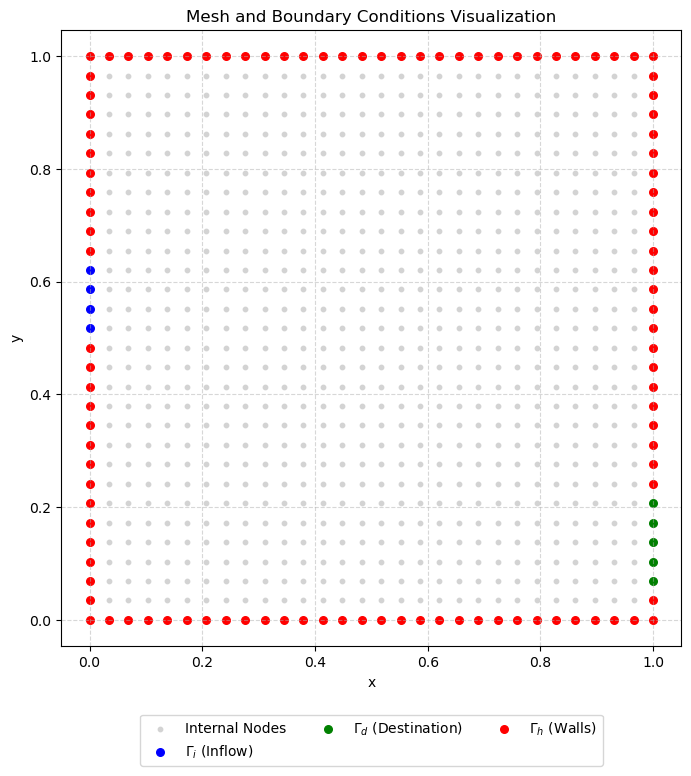

In [2]:
import matplotlib.pyplot as plt

def define_boundaries(N, start_in, count_in, start_dest, count_dest):
    """
    Defines indices for the three types of boundary conditions.
    
    Parameters:
        N: Number of nodes in one direction.
        start_in, count_in: Start index and height (in nodes) for inflow (left).
        start_dest, count_dest: Start index and height (in nodes) for destination (right).
    """
    gamma_i = [] # Inflow
    gamma_d = [] # Destination
    gamma_h = [] # Hard boundaries
    
    # All boundary indices
    for i in range(N):
        for j in range(N):
            # Check if node is on the perimeter
            if i == 0 or i == N-1 or j == 0 or j == N-1:
                # Left edge: Potential Inflow
                if i == 0:
                    if start_in <= j < start_in + count_in:
                        gamma_i.append((i, j))
                    else:
                        gamma_h.append((i, j))
                # Right edge: Potential Destination
                elif i == N-1:
                    if start_dest <= j < start_dest + count_dest:
                        gamma_d.append((i, j))
                    else:
                        gamma_h.append((i, j))
                # Top and Bottom edges (excluding corners already handled)
                else:
                    gamma_h.append((i, j))
                    
    return gamma_i, gamma_d, gamma_h

def plot_mesh_with_boundaries(X, Y, gamma_i, gamma_d, gamma_h):
    """
    Visualizes the mesh and the boundary types.
    """
    plt.figure(figsize=(8, 8))
    
    # Plot all mesh points in light gray
    plt.scatter(X, Y, color='lightgray', s=10, label='Internal Nodes')
    
    # Helper to extract X and Y coordinates from index lists
    def get_coords(idx_list):
        px = [X[i, j] for i, j in idx_list]
        py = [Y[i, j] for i, j in idx_list]
        return px, py

    # Plot specific boundaries
    ix, iy = get_coords(gamma_i)
    dx, dy = get_coords(gamma_d)
    hx, hy = get_coords(gamma_h)
    
    plt.scatter(ix, iy, color='blue', s=30, label='$\Gamma_i$ (Inflow)')
    plt.scatter(dx, dy, color='green', s=30, label='$\Gamma_d$ (Destination)')
    plt.scatter(hx, hy, color='red', s=30, label='$\Gamma_h$ (Walls)')
    
    plt.title("Mesh and Boundary Conditions Visualization")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('equal')
    plt.show()

# Example usage:
N = 30
x, y, X, Y, h = define_mesh(N)
g_i, g_d, g_h = define_boundaries(N, start_in=15, count_in=4, start_dest=2, count_dest=5)
plot_mesh_with_boundaries(X, Y, g_i, g_d, g_h)

## 3. Initialization

## 4. Main Computational Loop (Time Integration)

### 4.1 The Local Cost Function $c(x, y, t)$

The cost function $c$ represents the "effort" or "time" required to travel a unit of distance. In the Hughes model, it is the fundamental link between the current density ($\rho$) and the navigation strategy ($\phi$). It is defined as the reciprocal of the **potential speed** perceived by pedestrians.

We consider two main formulations for $c(\rho)$:

### Option A: The Velocity-Only Model (Simplified)
In the simplest form, as often used for numerical validation in **Huang et al. (2009)**, the cost depends only on the local walking speed $u(\rho)$:
$$c(\rho) = \frac{1}{u(\rho)} = \frac{1}{u_{max}(1 - \rho/\rho_{max})}$$
* **Behavior**: Pedestrians strictly minimize their travel time. 
* **Limitation**: The cost approaches infinity as $\rho \to \rho_{max}$, which requires numerical regularization.
* 
#### Numerical Regularization
To ensure the stability of the Eikonal solver (Fast Sweeping Method), we implement a safety threshold $u_{min}$ to prevent division by zero:
$$c(\rho) = \frac{1}{\max(u(\rho), u_{min})}$$

### Option B: The Hughes Model with Discomfort
To model more realistic behaviors where pedestrians avoid crowded areas proactively, an **incomfort function** $g(\rho)$ is introduced:
$$c(\rho) = \frac{1}{u(\rho) \cdot g(\rho)}$$
A common choice for the comfort potential is $g(\rho) = \exp(-\alpha \rho^2)$, leading to:
$$c(\rho) = \frac{e^{\alpha \rho^2}}{u_{max}(1 - \rho/\rho_{max})}$$
* **Behavior**: The cost increases exponentially with density. Pedestrians will prefer a longer path in a clear area over a shorter path through a dense crowd.

### Non-dimensionalization
For the numerical implementation, we adopt **dimensionless variables** as is standard in the literature (Huang et al., 2009). We set the maximum density $\rho_{max} = 1$ and the free-flow speed $u_{max} = 1$. Consequently, the local density $\rho$ represents the occupancy ratio ($\rho \in [0, 1]$), and the velocity $u(\rho)$ is a fraction of the maximum walking speed. This approach generalizes the results and ensures better numerical stability for the WENO scheme.

In [3]:
def compute_cost(rho, u_max=1.0, rho_max=1.0, alpha=0.5, mode='hughes'):
    """
    Computes the cost function c(rho).
    Modes: 'simple' (1/u), 'hughes' (1/(u*g))
    """
    # 1. Compute velocity u(rho)
    u = u_max * (1 - rho / rho_max)
    u = np.maximum(u, 0.05) # Safety threshold to avoid division by zero
    
    if mode == 'simple':
        return 1.0 / u
    
    elif mode == 'hughes':
        # Comfort function g(rho) = exp(-alpha * rho^2)
        # Cost c = 1/(u*g) = exp(alpha * rho^2) / u
        g_inv = np.exp(alpha * (rho**2))
        return g_inv / u

# Note: In the paper, Equation (12) often refers to this combined effect.

### 4.2 Eikonal Equation for Potential $\phi$
Based on **Formula (15)**, we solve for the potential field using the **Fast Sweeping Method**:
$$\|\nabla \phi\| = c, \quad \phi|_{\Gamma_d} = 0$$

### 4.3 Flux Magnitude $\|\mathbf{f}\|$
Based on **Formula (25)**, we compute the magnitude of the pedestrian flow:
$$\|\mathbf{f}\| = \rho \cdot u(\rho)$$

### 4.4 Flux Vector $\mathbf{f}$
Based on **Formula (26)**, we determine the flow direction (downward gradient of $\phi$):
$$\mathbf{f} = \|\mathbf{f}\| \mathbf{n} = \|\mathbf{f}\| \left( -\frac{\nabla \phi}{\|\nabla \phi\|} \right)$$

### 4.5 Conservation Law Update

Based on **Formula (24)**, we solve the transport equation using:
* **Lax–Friedrichs Flux Splitting** (Eq. 36)
* **5th-order WENO Reconstruction** (Eq. 31-35)
* **Euler Forward** or **TVD-RK3** time marching.

In [4]:
import numpy as np

def get_weno5_flux(f_stencil, rho_stencil, alpha):
    """
    WENO 5th-order numerical flux (Eq. 31-37).
    f_stencil:   Physical flux values at [i-2, i-1, i, i+1, i+2]
    rho_stencil: Density values at [i-2, i-1, i, i+1, i+2]
    alpha:       Max signal speed (Eq. 37)
    """
    # 1. Lax-Friedrichs Flux Splitting (Eq. 36)
    # Splits the flux into positive (f_plus) and negative (f_minus) parts 
    # to ensure stability based on the maximum signal speed alpha (Eq. 37).
    f_plus = 0.5 * (f_stencil + alpha * rho_stencil)
    f_minus = 0.5 * (f_stencil - alpha * rho_stencil)
    
    def reconstruct_weno(s):
        # 2. Third-order candidate stencils (Eq. 31)
        # These are the three possible parabolic reconstructions (q1, q2, q3).
        q1 = (1/3)*s[0] - (7/6)*s[1] + (11/6)*s[2]
        q2 = -(1/6)*s[1] + (5/6)*s[2] + (1/3)*s[3]
        q3 = (1/3)*s[2] + (5/6)*s[3] - (1/6)*s[4]
        
        # 3. Smoothness Indicators (Eq. 34)
        # Measures the "roughness" of the solution in each candidate stencil.
        # beta is small for smooth regions and large for shocks/discontinuities.
        beta1 = (13/12)*(s[0] - 2*s[1] + s[2])**2 + (0.25)*(s[0] - 4*s[1] + 3*s[2])**2
        beta2 = (13/12)*(s[1] - 2*s[2] + s[3])**2 + (0.25)*(s[1] - s[3])**2
        beta3 = (13/12)*(s[2] - 2*s[3] + s[4])**2 + (0.25)*(3*s[2] - 4*s[3] + s[4])**2
        
        # 4. Non-linear Weights (Eq. 32-33)
        # Assigns higher weights to smoother stencils to avoid oscillations.
        eps = 1e-6 # Parameter to avoid division by zero
        gamma = np.array([0.1, 0.6, 0.3]) # Optimal linear weights
        alpha_w = gamma / (eps + np.array([beta1, beta2, beta3]))**2
        omega = alpha_w / np.sum(alpha_w)
        
        return np.dot(omega, [q1, q2, q3])

    # Final numerical flux calculation (Eq. 31 and 36 combined)
    # The negative part uses a reversed stencil for symmetry
    flux_plus = reconstruct_weno(f_plus)
    flux_minus = reconstruct_weno(f_minus[::-1]) # [::-1] is here for the mirror symmetric procedure
    
    return flux_plus + flux_minus

def compute_d_rho_dt_at_point(i, j, rho_grid, f1_grid, f2_grid, dx, dy, alpha1, alpha2):
    """
    Computes the derivative of rho with respect to time at grid point (i, j)
    using strictly Equation (30) and the WENO5 flux function.
    """
    
    # --- X-DIRECTION FLUXES (f1) ---
    # To get flux at interface i+1/2, we need rho and f1 from i-2 to i+3 (6 points)
    # Stencil for interface i+1/2: indices [i-2, i-1, i, i+1, i+2, i+3]
    f1_stencil_right = f1_grid[i-2 : i+4, j]
    rho_stencil_right = rho_grid[i-2 : i+4, j]
    f1_hat_plushalf = get_weno5_flux(f1_stencil_right, rho_stencil_right, alpha1)
    
    # Stencil for interface i-1/2: indices [i-3, i-2, i-1, i, i+1, i+2]
    f1_stencil_left = f1_grid[i-3 : i+3, j]
    rho_stencil_left = rho_grid[i-3 : i+3, j]
    f1_hat_minushalf = get_weno5_flux(f1_stencil_left, rho_stencil_left, alpha1)
    
    # --- Y-DIRECTION FLUXES (f2) ---
    # Stencil for interface j+1/2: indices [j-2, j-1, j, j+1, j+2, j+3]
    f2_stencil_top = f2_grid[i, j-2 : j+4]
    rho_stencil_top = rho_grid[i, j-2 : j+4]
    f2_hat_plushalf = get_weno5_flux(f2_stencil_top, rho_stencil_top, alpha2)
    
    # Stencil for interface j-1/2: indices [j-3, j-2, j-1, j, j+1, j+2]
    f2_stencil_bottom = f2_grid[i, j-3 : j+3]
    rho_stencil_bottom = rho_grid[i, j-3 : j+3]
    f2_hat_minushalf = get_weno5_flux(f2_stencil_bottom, rho_stencil_bottom, alpha2)
    
    # --- EQUATION (30) ---
    # d_rho/dt = - (flux_difference_x / dx) - (flux_difference_y / dy)
    term_x = (f1_hat_plushalf - f1_hat_minushalf) / dx
    term_y = (f2_hat_plushalf - f2_hat_minushalf) / dy
    
    d_rho_dt = -(term_x + term_y)
    
    return d_rho_dt
